# FinTech Customer Transaction & Risk Analytics

## Project Overview

This project analyzes synthetic FinTech transaction data to evaluate customer behavior, transaction volume, fee revenue, failed payment activity, payment channel performance, and risk indicators.

The goal is to simulate the type of analysis used by FinTech companies, digital banks, payment platforms, and financial operations teams to monitor business performance and operational risk.

This project focuses on:
- Customer transaction behavior
- Revenue from transaction fees
- Failed payment analysis
- Payment channel performance
- Merchant category performance
- Customer segment analysis
- Risk flag detection
- Executive-level business insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import random

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

random.seed(42)
np.random.seed(42)

## 1. Create Synthetic Customer and Transaction Data

This project uses synthetic data created for portfolio and learning purposes. No real customer, company, employer, or financial institution data is used.

The dataset is designed to represent a U.S.-based FinTech platform that processes customer payments across different payment channels, merchant categories, and customer segments.

In [2]:
# Create synthetic customer profile data

num_customers = 650

states = [
    "MA", "NY", "CA", "TX", "FL", "WA", "IL", "PA", "GA", "NC",
    "VA", "NJ", "OH", "AZ", "CO"
]

segments = ["Standard", "Premium", "Small Business"]
age_groups = ["18-24", "25-34", "35-44", "45-54", "55+"]
risk_tiers = ["Low", "Medium", "High"]

customers = []

start_signup = datetime(2023, 1, 1)

for i in range(1, num_customers + 1):
    customer_id = f"CUST{i:05d}"
    signup_date = start_signup + timedelta(days=random.randint(0, 850))
    segment = random.choices(
        segments,
        weights=[0.65, 0.25, 0.10],
        k=1
    )[0]
    
    risk_tier = random.choices(
        risk_tiers,
        weights=[0.70, 0.23, 0.07],
        k=1
    )[0]
    
    customers.append({
        "customer_id": customer_id,
        "signup_date": signup_date.strftime("%Y-%m-%d"),
        "state": random.choice(states),
        "age_group": random.choice(age_groups),
        "customer_segment": segment,
        "risk_tier": risk_tier
    })

customers_df = pd.DataFrame(customers)

customers_df.head()

,customer_id,signup_date,state,age_group,customer_segment,risk_tier
0,CUST00001,2024-10-16,TX,25-34,Standard,Medium
1,CUST00002,2023-05-23,CO,55+,Premium,Low
2,CUST00003,2023-03-31,NY,25-34,Standard,Low
3,CUST00004,2023-08-27,TX,55+,Standard,Low
4,CUST00005,2024-03-05,OH,18-24,Standard,Low


In [3]:
# Create synthetic transaction data

num_transactions = 12000

merchant_categories = [
    "Grocery", "Utilities", "Digital Services", "Travel", "Retail",
    "Restaurants", "Healthcare", "Entertainment", "Money Transfer",
    "Subscription"
]

payment_channels = ["Mobile App", "Web", "API", "Card Terminal"]
payment_methods = ["Debit Card", "Credit Card", "ACH", "Wallet Balance"]
device_types = ["iOS", "Android", "Desktop", "POS", "API"]

transaction_rows = []

transaction_start = datetime(2025, 1, 1)
transaction_end = datetime(2025, 6, 30)
date_range_days = (transaction_end - transaction_start).days

for i in range(1, num_transactions + 1):
    customer = customers_df.sample(1).iloc[0]
    transaction_date = transaction_start + timedelta(days=random.randint(0, date_range_days))
    
    merchant_category = random.choices(
        merchant_categories,
        weights=[0.15, 0.10, 0.13, 0.07, 0.15, 0.12, 0.06, 0.07, 0.10, 0.05],
        k=1
    )[0]
    
    payment_channel = random.choices(
        payment_channels,
        weights=[0.50, 0.25, 0.15, 0.10],
        k=1
    )[0]
    
    payment_method = random.choices(
        payment_methods,
        weights=[0.40, 0.30, 0.20, 0.10],
        k=1
    )[0]
    
    device_type = random.choices(
        device_types,
        weights=[0.35, 0.35, 0.15, 0.10, 0.05],
        k=1
    )[0]
    
    if merchant_category == "Money Transfer":
        amount = round(np.random.gamma(shape=2.8, scale=95), 2)
    elif merchant_category == "Travel":
        amount = round(np.random.gamma(shape=3.0, scale=120), 2)
    elif merchant_category == "Utilities":
        amount = round(np.random.gamma(shape=2.5, scale=55), 2)
    else:
        amount = round(np.random.gamma(shape=2.0, scale=40), 2)
    
    amount = max(amount, 5)
    
    fee_rate = {
        "Debit Card": 0.012,
        "Credit Card": 0.022,
        "ACH": 0.006,
        "Wallet Balance": 0.004
    }[payment_method]
    
    fee_amount = round(amount * fee_rate, 2)
    
    base_failure_probability = 0.035
    
    if payment_method == "ACH":
        base_failure_probability += 0.020
    if payment_channel == "API":
        base_failure_probability += 0.015
    if customer["risk_tier"] == "High":
        base_failure_probability += 0.035
    if amount > 500:
        base_failure_probability += 0.020
    
    is_failed = random.random() < base_failure_probability
    
    if is_failed:
        transaction_status = "Failed"
        failure_reason = random.choices(
            ["Insufficient Funds", "Card Declined", "Bank Network Error", "Account Verification Failed", "Limit Exceeded"],
            weights=[0.35, 0.25, 0.18, 0.12, 0.10],
            k=1
        )[0]
        fee_amount = 0
    else:
        transaction_status = "Completed"
        failure_reason = "None"
    
    risk_score = 0
    
    if amount > 500:
        risk_score += 25
    if amount > 1000:
        risk_score += 20
    if customer["risk_tier"] == "Medium":
        risk_score += 15
    if customer["risk_tier"] == "High":
        risk_score += 35
    if merchant_category == "Money Transfer":
        risk_score += 15
    if payment_channel == "API":
        risk_score += 10
    if transaction_status == "Failed":
        risk_score += 20
    
    risk_score += random.randint(0, 15)
    risk_score = min(risk_score, 100)
    
    if risk_score >= 70:
        risk_flag = "High Risk"
    elif risk_score >= 40:
        risk_flag = "Medium Risk"
    else:
        risk_flag = "Low Risk"
    
    transaction_rows.append({
        "transaction_id": f"TXN{i:07d}",
        "transaction_date": transaction_date.strftime("%Y-%m-%d"),
        "customer_id": customer["customer_id"],
        "state": customer["state"],
        "age_group": customer["age_group"],
        "customer_segment": customer["customer_segment"],
        "risk_tier": customer["risk_tier"],
        "merchant_category": merchant_category,
        "payment_channel": payment_channel,
        "payment_method": payment_method,
        "device_type": device_type,
        "transaction_amount": amount,
        "fee_amount": fee_amount,
        "transaction_status": transaction_status,
        "failure_reason": failure_reason,
        "risk_score": risk_score,
        "risk_flag": risk_flag
    })

transactions_df = pd.DataFrame(transaction_rows)

transactions_df.head()

,transaction_id,transaction_date,customer_id,state,age_group,customer_segment,risk_tier,merchant_category,payment_channel,payment_method,device_type,transaction_amount,fee_amount,transaction_status,failure_reason,risk_score,risk_flag
0,TXN0000001,2025-01-03,CUST00638,MA,18-24,Small Business,Low,Grocery,Mobile App,Debit Card,POS,59.54,0.71,Completed,None,15,Low Risk
1,TXN0000002,2025-01-19,CUST00485,AZ,55+,Standard,Low,Utilities,Mobile App,ACH,iOS,76.86,0.46,Completed,None,9,Low Risk
2,TXN0000003,2025-02-05,CUST00138,NC,45-54,Standard,Medium,Travel,API,ACH,Android,787.72,4.73,Completed,None,52,Medium Risk
3,TXN0000004,2025-05-16,CUST00246,CO,55+,Standard,Low,Retail,Web,Debit Card,Android,115.00,1.38,Completed,None,4,Low Risk
4,TXN0000005,2025-04-16,CUST00475,VA,35-44,Premium,Low,Restaurants,Mobile App,Debit Card,POS,151.79,1.82,Completed,None,3,Low Risk


In [4]:
# Save datasets to the data folder

data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

customers_df.to_csv(data_dir / "customer_profiles.csv", index=False)
transactions_df.to_csv(data_dir / "fintech_transactions.csv", index=False)

print("Customer dataset saved:", data_dir / "customer_profiles.csv")
print("Transaction dataset saved:", data_dir / "fintech_transactions.csv")
print("Customer rows:", len(customers_df))
print("Transaction rows:", len(transactions_df))

Customer dataset saved: ..\data\customer_profiles.csv
Transaction dataset saved: ..\data\fintech_transactions.csv
Customer rows: 650
Transaction rows: 12000


## 2. Load and Review the Data

After creating the synthetic data, the datasets are loaded from the CSV files to simulate a real analyst workflow.

In [5]:
customers = pd.read_csv("../data/customer_profiles.csv")
transactions = pd.read_csv("../data/fintech_transactions.csv")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
transactions["month"] = transactions["transaction_date"].dt.to_period("M").astype(str)

transactions.head()

,transaction_id,transaction_date,customer_id,state,age_group,customer_segment,risk_tier,merchant_category,payment_channel,payment_method,device_type,transaction_amount,fee_amount,transaction_status,failure_reason,risk_score,risk_flag,month
0,TXN0000001,2025-01-03,CUST00638,MA,18-24,Small Business,Low,Grocery,Mobile App,Debit Card,POS,59.54,0.71,Completed,NaN,15,Low Risk,2025-01
1,TXN0000002,2025-01-19,CUST00485,AZ,55+,Standard,Low,Utilities,Mobile App,ACH,iOS,76.86,0.46,Completed,NaN,9,Low Risk,2025-01
2,TXN0000003,2025-02-05,CUST00138,NC,45-54,Standard,Medium,Travel,API,ACH,Android,787.72,4.73,Completed,NaN,52,Medium Risk,2025-02
3,TXN0000004,2025-05-16,CUST00246,CO,55+,Standard,Low,Retail,Web,Debit Card,Android,115.00,1.38,Completed,NaN,4,Low Risk,2025-05
4,TXN0000005,2025-04-16,CUST00475,VA,35-44,Premium,Low,Restaurants,Mobile App,Debit Card,POS,151.79,1.82,Completed,NaN,3,Low Risk,2025-04


In [6]:
print("Transactions shape:", transactions.shape)
print("Customers shape:", customers.shape)

transactions.info()

Transactions shape: (12000, 18)
Customers shape: (650, 6)
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      12000 non-null  str           
 1   transaction_date    12000 non-null  datetime64[us]
 2   customer_id         12000 non-null  str           
 3   state               12000 non-null  str           
 4   age_group           12000 non-null  str           
 5   customer_segment    12000 non-null  str           
 6   risk_tier           12000 non-null  str           
 7   merchant_category   12000 non-null  str           
 8   payment_channel     12000 non-null  str           
 9   payment_method      12000 non-null  str           
 10  device_type         12000 non-null  str           
 11  transaction_amount  12000 non-null  float64       
 12  fee_amount          12000 non-null  float64       
 13 

## 3. Executive KPI Summary

This section calculates key business metrics that would be useful for a FinTech operations or business analytics team.

In [7]:
total_transactions = len(transactions)
completed_transactions = (transactions["transaction_status"] == "Completed").sum()
failed_transactions = (transactions["transaction_status"] == "Failed").sum()
failure_rate = failed_transactions / total_transactions
total_volume = transactions.loc[transactions["transaction_status"] == "Completed", "transaction_amount"].sum()
total_fee_revenue = transactions["fee_amount"].sum()
average_transaction_value = transactions.loc[transactions["transaction_status"] == "Completed", "transaction_amount"].mean()
high_risk_transactions = (transactions["risk_flag"] == "High Risk").sum()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Completed Transactions",
        "Failed Transactions",
        "Failure Rate",
        "Total Completed Transaction Volume",
        "Total Fee Revenue",
        "Average Completed Transaction Value",
        "High Risk Transactions"
    ],
    "Value": [
        total_transactions,
        completed_transactions,
        failed_transactions,
        f"{failure_rate:.2%}",
        f"${total_volume:,.2f}",
        f"${total_fee_revenue:,.2f}",
        f"${average_transaction_value:,.2f}",
        high_risk_transactions
    ]
})

kpi_summary

,Metric,Value
0,Total Transactions,12000
1,Completed Transactions,11466
2,Failed Transactions,534
3,Failure Rate,4.45%
4,Total Completed Transaction Volume,"$1,386,580.39"
5,Total Fee Revenue,"$17,975.92"
6,Average Completed Transaction Value,$120.93
7,High Risk Transactions,37


## 4. Monthly Transaction and Revenue Trends

Monthly trend analysis helps the business understand growth patterns, transaction behavior, and revenue movement over time.

In [8]:
monthly_summary = (
    transactions
    .groupby("month")
    .agg(
        total_transactions=("transaction_id", "count"),
        completed_transactions=("transaction_status", lambda x: (x == "Completed").sum()),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum")
    )
    .reset_index()
)

monthly_summary["failure_rate"] = (
    monthly_summary["failed_transactions"] / monthly_summary["total_transactions"]
)

monthly_summary

,month,total_transactions,completed_transactions,failed_transactions,transaction_volume,fee_revenue,failure_rate
0,2025-01,2020,1921,99,"247,556.73","3,050.94",0.05
1,2025-02,1892,1811,81,"240,143.86","2,972.34",0.04
2,2025-03,2053,1961,92,"243,695.65","3,019.64",0.04
3,2025-04,2007,1922,85,"234,669.96","2,900.48",0.04
4,2025-05,2054,1958,96,"256,862.11","3,130.76",0.05
5,2025-06,1974,1893,81,"232,003.80","2,901.76",0.04


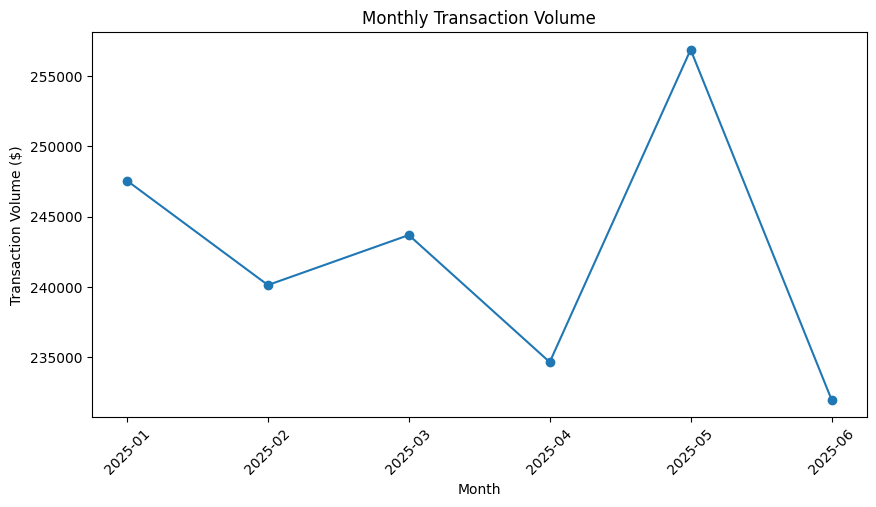

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["transaction_volume"], marker="o")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transaction Volume ($)")
plt.xticks(rotation=45)
plt.show()

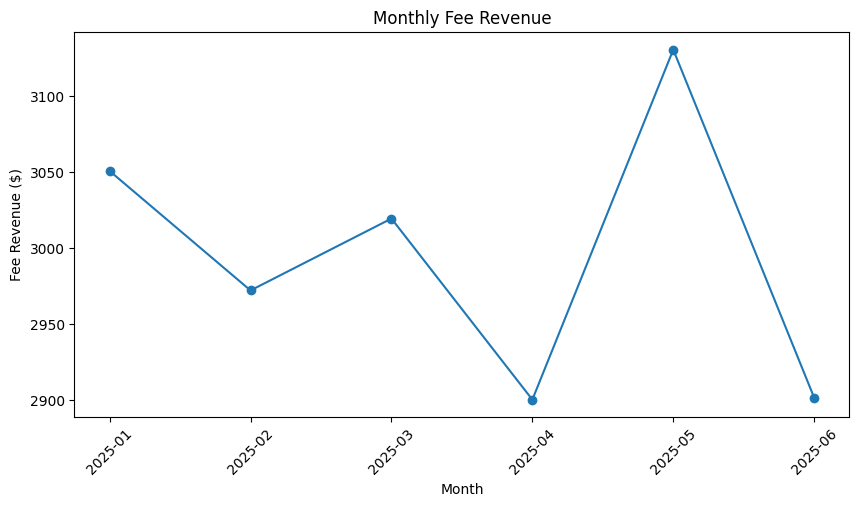

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["fee_revenue"], marker="o")
plt.title("Monthly Fee Revenue")
plt.xlabel("Month")
plt.ylabel("Fee Revenue ($)")
plt.xticks(rotation=45)
plt.show()

## 5. Payment Channel Performance

This section compares transaction volume, fee revenue, failed transactions, and failure rates by payment channel.

In [11]:
channel_summary = (
    transactions
    .groupby("payment_channel")
    .agg(
        total_transactions=("transaction_id", "count"),
        completed_transactions=("transaction_status", lambda x: (x == "Completed").sum()),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

channel_summary["failure_rate"] = (
    channel_summary["failed_transactions"] / channel_summary["total_transactions"]
)

channel_summary.sort_values("failure_rate", ascending=False)

,payment_channel,total_transactions,completed_transactions,failed_transactions,transaction_volume,fee_revenue,avg_risk_score,failure_rate
0,API,1854,1739,115,"227,796.15","2,719.44",26.98,0.06
1,Card Terminal,1210,1154,56,"154,365.47","1,893.78",16.46,0.05
2,Mobile App,6031,5767,264,"716,495.44","8,916.66",16.40,0.04
3,Web,2905,2806,99,"356,275.05","4,446.04",16.20,0.03


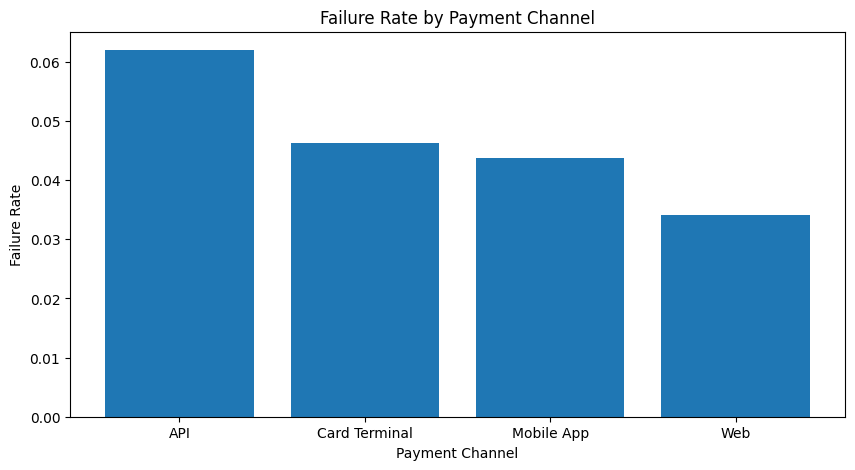

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(channel_summary["payment_channel"], channel_summary["failure_rate"])
plt.title("Failure Rate by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Failure Rate")
plt.show()

## 6. Merchant Category Performance

Merchant category analysis helps identify where customers are spending, which categories generate the most volume, and which categories may carry higher risk.

In [13]:
merchant_summary = (
    transactions
    .groupby("merchant_category")
    .agg(
        total_transactions=("transaction_id", "count"),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum"),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

merchant_summary["failure_rate"] = (
    merchant_summary["failed_transactions"] / merchant_summary["total_transactions"]
)

merchant_summary.sort_values("transaction_volume", ascending=False)

,merchant_category,total_transactions,transaction_volume,fee_revenue,failed_transactions,avg_risk_score,failure_rate
4,Money Transfer,1243,"328,372.15","4,090.30",52,33.58,0.04
8,Travel,770,"264,425.97","3,143.15",36,20.96,0.05
9,Utilities,1178,"161,564.59","2,121.17",42,15.86,0.04
6,Retail,1822,"145,516.39","1,792.16",77,15.90,0.04
2,Grocery,1776,"143,770.41","1,775.07",76,15.62,0.04
0,Digital Services,1553,"119,683.16","1,482.89",75,15.86,0.05
5,Restaurants,1477,"116,673.41","1,447.99",60,16.10,0.04
1,Entertainment,833,"66,634.61",809.19,46,15.62,0.06
3,Healthcare,739,"60,466.06",734.20,37,15.21,0.05
7,Subscription,609,"47,825.36",579.80,33,16.38,0.05


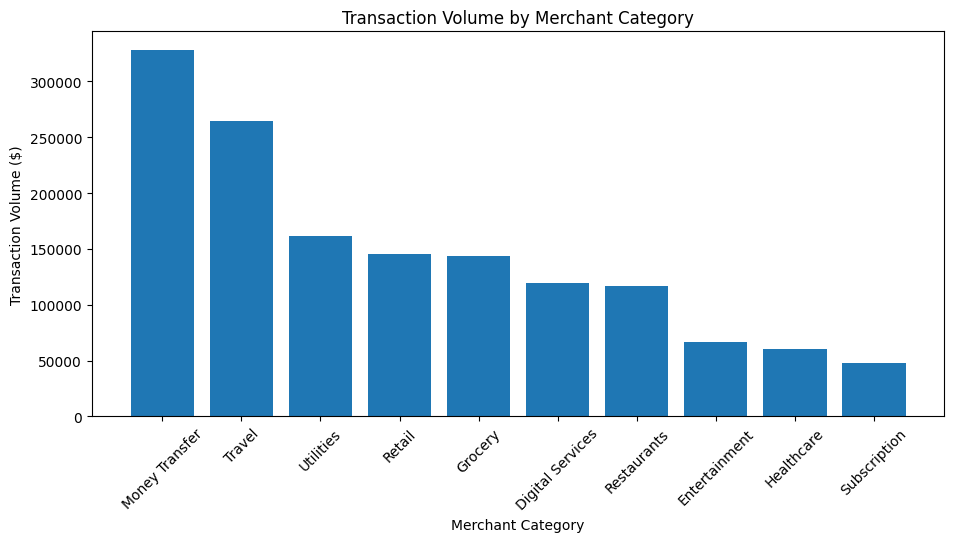

In [14]:
top_merchants = merchant_summary.sort_values("transaction_volume", ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(top_merchants["merchant_category"], top_merchants["transaction_volume"])
plt.title("Transaction Volume by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Transaction Volume ($)")
plt.xticks(rotation=45)
plt.show()

## 7. Customer Segment Analysis

Customer segmentation helps the business compare behavior across Standard, Premium, and Small Business users.

In [15]:
segment_summary = (
    transactions
    .groupby("customer_segment")
    .agg(
        total_transactions=("transaction_id", "count"),
        unique_customers=("customer_id", "nunique"),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum"),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        avg_transaction_amount=("transaction_amount", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

segment_summary["failure_rate"] = (
    segment_summary["failed_transactions"] / segment_summary["total_transactions"]
)

segment_summary.sort_values("transaction_volume", ascending=False)

,customer_segment,total_transactions,unique_customers,transaction_volume,fee_revenue,failed_transactions,avg_transaction_amount,avg_risk_score,failure_rate
2,Standard,7972,430,"967,137.62","11,831.61",364,121.32,18.26,0.05
0,Premium,2773,153,"340,424.44","4,325.47",116,122.76,18.38,0.04
1,Small Business,1255,67,"147,370.05","1,818.84",54,117.43,15.42,0.04


## 8. Risk Flag Analysis

Risk flag analysis helps identify higher-risk transaction patterns. This is useful for fraud operations, compliance monitoring, payment operations, and customer risk review teams.

In [16]:
risk_summary = (
    transactions
    .groupby("risk_flag")
    .agg(
        total_transactions=("transaction_id", "count"),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum"),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        avg_transaction_amount=("transaction_amount", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

risk_summary["failure_rate"] = (
    risk_summary["failed_transactions"] / risk_summary["total_transactions"]
)

risk_summary.sort_values("avg_risk_score", ascending=False)

,risk_flag,total_transactions,transaction_volume,fee_revenue,failed_transactions,avg_transaction_amount,avg_risk_score,failure_rate
0,High Risk,37,"17,475.41",129.10,15,472.31,78.49,0.41
2,Medium Risk,1048,"221,948.50","2,460.50",201,211.78,48.28,0.19
1,Low Risk,10915,"1,215,508.20","15,386.32",318,111.36,14.88,0.03


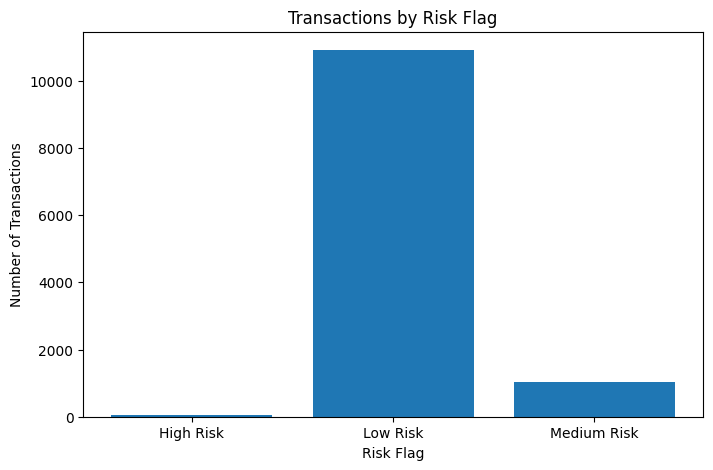

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(risk_summary["risk_flag"], risk_summary["total_transactions"])
plt.title("Transactions by Risk Flag")
plt.xlabel("Risk Flag")
plt.ylabel("Number of Transactions")
plt.show()

## 9. Failed Transaction Analysis

Failed transactions can create customer experience problems, operational workload, and lost revenue. This section reviews failed payment reasons.

In [18]:
failure_summary = (
    transactions[transactions["transaction_status"] == "Failed"]
    .groupby("failure_reason")
    .agg(
        failed_transactions=("transaction_id", "count"),
        avg_transaction_amount=("transaction_amount", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
    .sort_values("failed_transactions", ascending=False)
)

failure_summary

,failure_reason,failed_transactions,avg_transaction_amount,avg_risk_score
3,Insufficient Funds,186,127.38,38.85
2,Card Declined,134,120.38,38.77
1,Bank Network Error,114,137.05,39.13
0,Account Verification Failed,60,129.75,39.02
4,Limit Exceeded,40,128.00,38.17


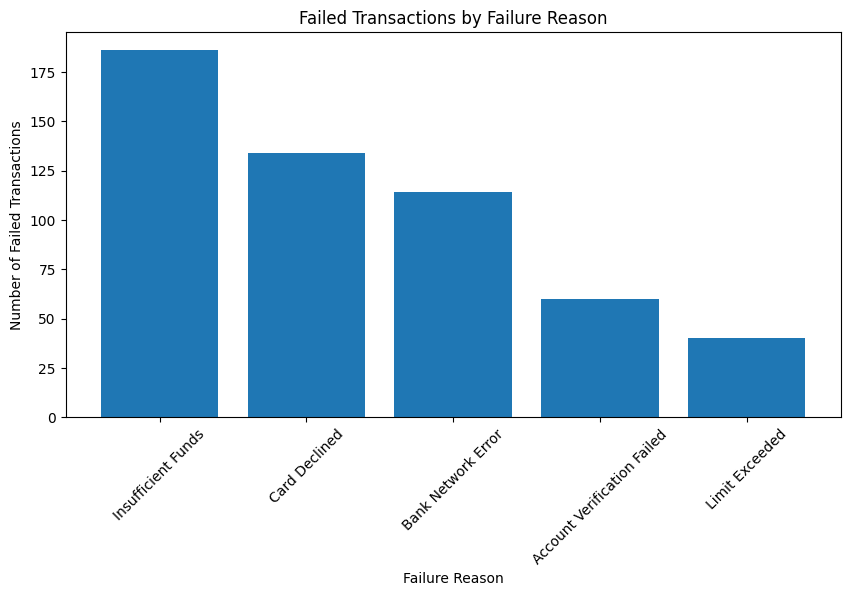

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(failure_summary["failure_reason"], failure_summary["failed_transactions"])
plt.title("Failed Transactions by Failure Reason")
plt.xlabel("Failure Reason")
plt.ylabel("Number of Failed Transactions")
plt.xticks(rotation=45)
plt.show()

## 10. Customers With Unusual Activity

This section identifies customers with high transaction volume, high failure counts, or high-risk transaction patterns.

In [20]:
customer_activity = (
    transactions
    .groupby("customer_id")
    .agg(
        total_transactions=("transaction_id", "count"),
        completed_transactions=("transaction_status", lambda x: (x == "Completed").sum()),
        failed_transactions=("transaction_status", lambda x: (x == "Failed").sum()),
        transaction_volume=("transaction_amount", "sum"),
        fee_revenue=("fee_amount", "sum"),
        avg_risk_score=("risk_score", "mean"),
        high_risk_transactions=("risk_flag", lambda x: (x == "High Risk").sum())
    )
    .reset_index()
)

customer_activity["failure_rate"] = (
    customer_activity["failed_transactions"] / customer_activity["total_transactions"]
)

customer_activity.sort_values(
    ["transaction_volume", "high_risk_transactions"],
    ascending=False
).head(10)

,customer_id,total_transactions,completed_transactions,failed_transactions,transaction_volume,fee_revenue,avg_risk_score,high_risk_transactions,failure_rate
145,CUST00146,28,26,2,"5,141.53",59.69,13.18,0,0.07
580,CUST00581,21,20,1,"4,816.05",49.83,32.00,1,0.05
600,CUST00601,32,30,2,"4,602.68",64.88,11.38,0,0.06
164,CUST00165,19,18,1,"4,591.47",63.15,18.42,0,0.05
424,CUST00425,23,21,2,"4,491.74",47.50,14.30,0,0.09
213,CUST00214,28,27,1,"4,288.49",50.71,14.04,0,0.04
457,CUST00458,29,28,1,"4,284.57",57.42,13.34,0,0.03
92,CUST00093,29,29,0,"4,269.79",50.23,26.90,0,0.00
26,CUST00027,23,23,0,"4,251.93",53.72,15.83,0,0.00
218,CUST00219,24,21,3,"4,240.15",45.02,18.38,0,0.12


## 11. Final Business Insights

In [21]:
highest_volume_segment = segment_summary.sort_values("transaction_volume", ascending=False).iloc[0]["customer_segment"]
highest_failure_channel = channel_summary.sort_values("failure_rate", ascending=False).iloc[0]["payment_channel"]
highest_volume_merchant = merchant_summary.sort_values("transaction_volume", ascending=False).iloc[0]["merchant_category"]
top_failure_reason = failure_summary.iloc[0]["failure_reason"]

print("Final Business Insights")
print("------------------------")
print(f"Total transactions analyzed: {total_transactions:,}")
print(f"Total completed transaction volume: ${total_volume:,.2f}")
print(f"Total fee revenue: ${total_fee_revenue:,.2f}")
print(f"Overall failure rate: {failure_rate:.2%}")
print(f"Customer segment with highest transaction volume: {highest_volume_segment}")
print(f"Payment channel with highest failure rate: {highest_failure_channel}")
print(f"Merchant category with highest transaction volume: {highest_volume_merchant}")
print(f"Most common failed transaction reason: {top_failure_reason}")
print(f"High-risk transactions identified: {high_risk_transactions:,}")

Final Business Insights
------------------------
Total transactions analyzed: 12,000
Total completed transaction volume: $1,386,580.39
Total fee revenue: $17,975.92
Overall failure rate: 4.45%
Customer segment with highest transaction volume: Standard
Payment channel with highest failure rate: API
Merchant category with highest transaction volume: Money Transfer
Most common failed transaction reason: Insufficient Funds
High-risk transactions identified: 37


## Conclusion

This project demonstrates how a FinTech company can use transaction analytics to monitor business performance, customer behavior, revenue, failed payments, and risk indicators.

The analysis showed how Python can be used to create and analyze transaction data, how business KPIs can be calculated, and how operational risk can be reviewed through customer, channel, merchant, and risk-level analysis.

This project is useful for demonstrating practical skills for Financial Analyst, Operations Analyst, Business Analyst, FinTech Analyst, and Data Analyst roles.